In [1]:
%load_ext autoreload
%autoreload 2
import os,sys
import numpy as np
import pandas as pd
import scanpy as sc

import pseudodynamics as pdp


/usr/local/lib/python3.10/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
# notebook_path = globals().get('__vsc_ipynb_file__')
os.chdir("/rds/user/wz369/hpc-work/PINN_dynamics")
import scripts.fate_eval_pipeline as fate_eval

In [3]:
adata = sc.read_h5ad("data/klein_addpop.h5ad")
ad_13k = sc.read_h5ad("data/Weinreb_13k_clean.h5ad")

F_obs = pd.read_csv("data/klein/F_obs.csv", index_col=0)
F_obs = F_obs[F_obs.index.astype(str).isin(adata.obs_names)]

In [4]:
seleced = adata[F_obs.index.astype(str)].copy()

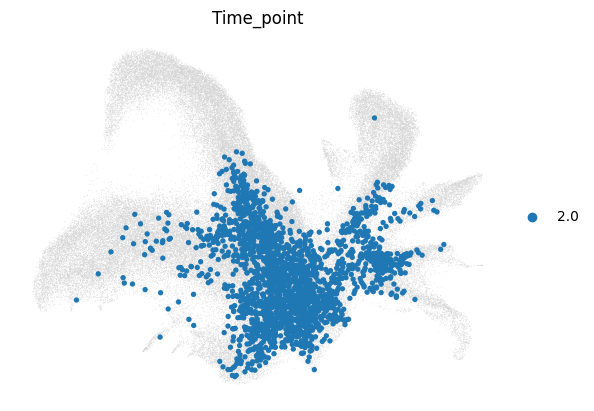

In [5]:
fig = sc.pl.umap(adata, return_fig=True, show=False, frameon=False)
sc.pl.umap(adata[F_obs.index.astype(str)].copy(), color='Time_point', frameon=False, ax=fig.gca())

# print the clone cell type distribution

In [6]:
import re

def parse_filename(filename):
    pattern = r't([0-9.]+)_n([0-9.]+)_([a-zA-Z]+)_fate_eval\.csv'
    match = re.match(pattern, filename)
    
    if match:
        time = float(match.group(1))
        noise = float(match.group(2))
        sim_fun = match.group(3)
        
        return {
            'time': time,
            'noise': noise, 
            'sim_fun': sim_fun
        }
    else:
        return None

In [7]:
pdp_result_dir = "/rds/user/wz369/hpc-work/pseudodynamics_plus/results/pseudodynamics+"

config_names = os.listdir(pdp_result_dir)

fate_acc_df_list = []

for config_name in os.listdir(pdp_result_dir):
    config_path = os.path.join(pdp_result_dir, config_name)
    for csv in os.listdir(config_path):
        if csv.endswith("fate_eval.csv"):
            df = pd.read_csv(os.path.join(config_path, csv))

            params = parse_filename(csv) # use regex to get time noise and sim func

            # label the df
            df["time"] = params["time"]
            df["noise"] = params["noise"]
            df["sim_fun"] = params["sim_fun"]
            df['config'] = config_name

            fate_acc_df_list.append(df)


fate_acc_df = pd.concat(fate_acc_df_list, axis=0)

In [8]:
fate_acc_df

,accuracy,pearson_r,pearson_p,n_start_cells,n_sims,k_nn,obsm_key,n_dims,t_end_norm,noise_scale,model_dir,time,noise,sim_fun,config
0,0.370261,0.719713,0.018938,2031,100,15,DM_EigenVectors,10,6.0,1.5,/rds/user/wz369/hpc-work/pseudodynamics_plus/l...,6.0,1.5,sde,klein_DM_10_lD1_lv1_lgNone
0,0.370261,0.700191,0.024151,2031,100,15,DM_EigenVectors,10,6.0,1.0,/rds/user/wz369/hpc-work/pseudodynamics_plus/l...,6.0,1.0,ode,klein_DM_10_lD1_lv1_lgNone
0,0.370261,0.700191,0.024151,2031,100,15,DM_EigenVectors,10,0.5,1.0,/rds/user/wz369/hpc-work/pseudodynamics_plus/l...,0.5,1.0,ode,klein_DM_10_lD1_lv1_lgNone
0,0.007878,-0.402216,0.249207,2031,100,15,DM_EigenVectors,10,0.5,1.0,/rds/user/wz369/hpc-work/pseudodynamics_plus/l...,0.5,1.0,sb,klein_DM_10_lD1_lv1_lgNone
0,0.006893,-0.462916,0.177892,2031,100,15,DM_EigenVectors,10,0.2,2.0,/rds/user/wz369/hpc-work/pseudodynamics_plus/l...,0.2,2.0,sb,klein_DM_10_lD1_lv1_lgNone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,0.340719,0.826539,0.003195,2031,100,15,X_pca_scaled,30,6.0,1.5,/rds/user/wz369/hpc-work/pseudodynamics_plus/l...,6.0,1.5,sb,klein_PC30_lD1_cfm2_lgNone
0,0.253570,0.751880,0.012137,2031,100,15,X_pca_scaled,30,4.0,1.5,/rds/user/wz369/hpc-work/pseudodynamics_plus/l...,4.0,1.5,sde,klein_PC30_lD1_cfm2_lgNone
0,0.222550,0.749881,0.012500,2031,100,15,X_pca_scaled,30,4.0,1.0,/rds/user/wz369/hpc-work/pseudodynamics_plus/l...,4.0,1.0,ode,klein_PC30_lD1_cfm2_lgNone
0,0.043821,0.968436,0.000004,2031,100,15,X_pca_scaled,30,0.5,2.0,/rds/user/wz369/hpc-work/pseudodynamics_plus/l...,0.5,2.0,sde,klein_PC30_lD1_cfm2_lgNone


In [9]:
top_performed = fate_acc_df.groupby(["config","obsm_key","sim_fun"]).agg({"accuracy":"max", "pearson_r":"max"}).reset_index()
top_performed.head(3)

,config,obsm_key,sim_fun,accuracy,pearson_r
0,klein_DM_10_lD10_lv1_lgNone,DM_EigenVectors,ode,0.329394,0.576442
1,klein_DM_10_lD10_lv1_lgNone,DM_EigenVectors,sb,0.045298,-0.324772
2,klein_DM_10_lD10_lv1_lgNone,DM_EigenVectors,sde,0.329394,0.576369


In [10]:
top_performed.tail(3)

,config,obsm_key,sim_fun,accuracy,pearson_r
39,klein_PC_30_lD1_lv1_lgNone,X_pca_scaled,ode,0.108321,0.975764
40,klein_PC_30_lD1_lv1_lgNone,X_pca_scaled,sb,0.457410,0.973500
41,klein_PC_30_lD1_lv1_lgNone,X_pca_scaled,sde,0.121615,0.975773


# FOR DM

In [11]:
# look for the best config for DM

In [12]:
OT_config = "klein_DM_10_lD1_cfm10_lgNone_b1024"
time = 6.0	
noise = 1.0	
sim_fun = "ode"

# F_hat_nonOT = "klein_DM_10_lD1_lv1_lgNone"

F_hat_OT = pd.read_csv(os.path.join(pdp_result_dir, config_name, f"t{time}_n{noise}_{sim_fun}_fate_eval_F_hat.csv"), index_col=0)

In [13]:
non_OT_config = "klein_DM_10_lD1_lv1_lgNone"
time = 4.0	
noise = 2.0	
sim_fun = "sde"

# F_hat_nonOT = "klein_DM_10_lD1_lv1_lgNone"

F_hat_nonOT = pd.read_csv(os.path.join(pdp_result_dir, config_name, f"t{time}_n{noise}_{sim_fun}_fate_eval_F_hat.csv"), index_col=0)

In [14]:
true_ct = F_obs.idxmax(axis=1).values

pred_ct = F_hat_nonOT.idxmax(axis=1).values 
zero_idx = np.where(F_hat_nonOT.sum(axis=1).values == 0)[0]
for idx in zero_idx:
    pred_ct[idx] = "Undifferentiated"

F_hat_nonOT['match_']  = pred_ct == true_ct
F_hat_nonOT['true_ct'] = true_ct
F_hat_nonOT['clone'] = seleced.obs['clones'].values.copy

In [15]:
F_hat_nonOT

,Baso,Ccr7_DC,Eos,Erythroid,Lymphoid,Mast,Meg,Monocyte,Neutrophil,pDC,match_,true_ct,clone
13199,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.92,0.0,False,Monocyte,<built-in method copy of Categorical object at...
13210,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.60,0.0,True,Neutrophil,<built-in method copy of Categorical object at...
13226,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,False,Meg,<built-in method copy of Categorical object at...
13235,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,False,Baso,<built-in method copy of Categorical object at...
13256,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,False,Monocyte,<built-in method copy of Categorical object at...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69313,0.0,0.0,0.0,0.0,0.0,0.0,0.02,0.0,0.00,0.0,True,Meg,<built-in method copy of Categorical object at...
69317,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.89,0.0,False,Monocyte,<built-in method copy of Categorical object at...
69322,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,1.00,0.0,False,Meg,<built-in method copy of Categorical object at...
69324,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,False,Baso,<built-in method copy of Categorical object at...


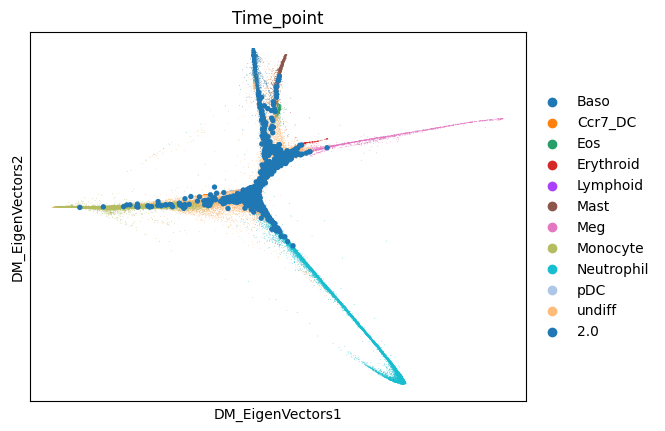

In [181]:
fig = sc.pl.embedding(adata, basis='DM_EigenVectors', color='Annotation', show=False, return_fig=True) 
sc.pl.embedding(seleced, basis='DM_EigenVectors', color='Time_point', ax=fig.gca()) 

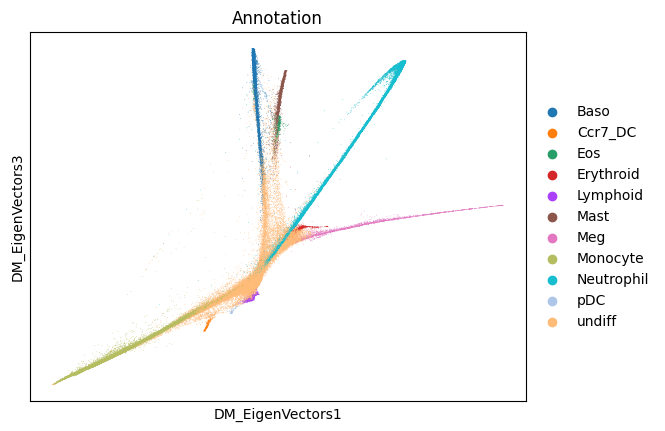

In [178]:
sc.pl.embedding(adata, 'DM_EigenVectors', components="1,3", color='Annotation') 

In [168]:
np.any(F_obs.sum(axis=1)==0)

False

In [55]:
clones = adata[F_obs.index].obs['clones'].unique()

In [ ]:
adata.obs[['clones', 'Annotation']].crosstab()

,clones,Annotation
0,Clone_573,undiff
1,Clone_1440,undiff
2,Clone_394,Monocyte
3,Clone_nan,Neutrophil
4,Clone_1972,undiff
...,...,...
130882,Clone_nan,undiff
130883,Clone_1374,undiff
130884,Clone_nan,Monocyte
130885,Clone_nan,Monocyte


In [ ]:
clone_fate_df = pd.crosstab(adata.obs['clones'].values, adata.obs['Annotation'].values)
clone_fate_df.pop('undiff')
clone_size = clone_fate_df.values.sum(axis=1, keepdims=True)
clone_fate_df = clone_fate_df / clone_size
clone_fate_df['clone_size'] = clone_size
clone_fate_df = clone_fate_df.dropna()

In [69]:
eval_clones = adata[F_obs.index].obs['clones'].unique()

In [155]:
eval_clones

['Clone_nan', 'Clone_4541', 'Clone_3513', 'Clone_657', 'Clone_1001', ..., 'Clone_558', 'Clone_1786', 'Clone_5073', 'Clone_3962', 'Clone_4515']
Length: 535
Categories (535, object): ['Clone_19', 'Clone_62', 'Clone_72', 'Clone_84', ..., 'Clone_5781', 'Clone_5814', 'Clone_5843', 'Clone_nan']

In [71]:
clone_fate_df

col_0,Baso,Ccr7_DC,Eos,Erythroid,Lymphoid,Mast,Meg,Monocyte,Neutrophil,pDC,clone_size
row_0,,,,,,,,,,,
Clone_1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.00000,20
Clone_2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.00000,14
Clone_4,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,9
Clone_5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.00000,4
Clone_6,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,1
...,...,...,...,...,...,...,...,...,...,...,...
Clone_5858,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.00000,4
Clone_5860,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,1
Clone_5861,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000,0.00000,0.000000,0.00000,2


In [72]:
clone_fate_df.loc['Clone_1']

col_0
Baso           0.0
Ccr7_DC        0.0
Eos            0.0
Erythroid      0.0
Lymphoid       0.0
Mast           0.0
Meg            0.0
Monocyte       0.0
Neutrophil     1.0
pDC            0.0
clone_size    20.0
Name: Clone_1, dtype: float64

In [ ]:
# look for the F_hat

In [ ]:
fate_acc_df